In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('accidents.csv', skiprows=1)
print(df.shape)

(30, 3)


In [3]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

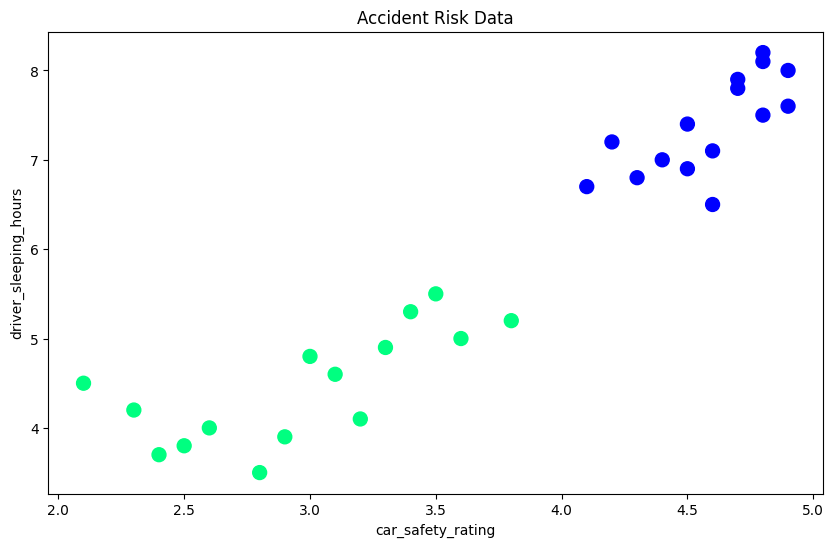

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.xlabel('car_safety_rating')
plt.ylabel('driver_sleeping_hours')
plt.title('Accident Risk Data')
plt.show()

In [5]:
# Convert labels: 0 -> -1, 1 -> 1  (required for hinge-loss perceptron)
y_signed = np.where(y == 0, -1, 1)

In [6]:
def perceptron(X, y):
    w1 = w2 = b = 1
    lr = 0.1
    for j in range(1000):
        for i in range(X.shape[0]):
            z = w1*X[i][0] + w2*X[i][1] + b
            if z * y[i] < 0:
                w1 = w1 + lr * y[i] * X[i][0]
                w2 = w2 + lr * y[i] * X[i][1]
                b  = b  + lr * y[i]
    return w1, w2, b

In [7]:
w1, w2, b = perceptron(X, y_signed)

In [8]:
print(b)

0.9


In [9]:
m = -(w1 / w2)
c = -(b / w2)
print(m, c)

0.6296296296296294 3.3333333333333326


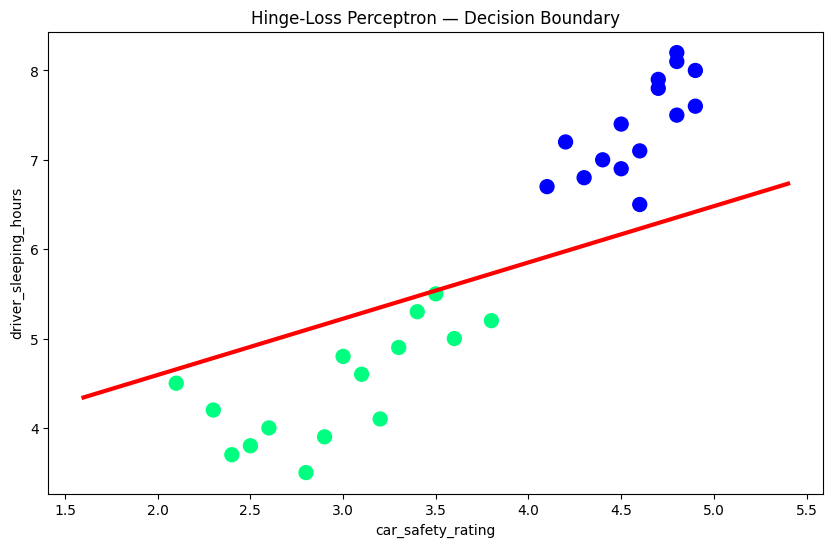

In [10]:
x_input = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100)
y_input = m * x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.xlabel('car_safety_rating')
plt.ylabel('driver_sleeping_hours')
plt.title('Hinge-Loss Perceptron — Decision Boundary')
plt.show()